<a href="https://colab.research.google.com/github/di-claro-batera/faculdade_data_science/blob/main/Otimiza%C3%A7%C3%A3o_topologia_rede_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sklearn.datasets
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

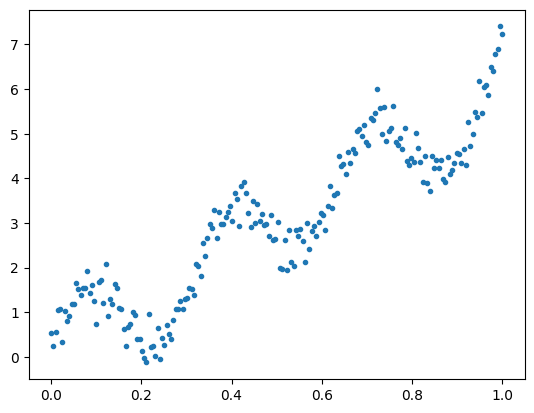

(200,)


In [27]:
np.random.seed(0)
X = np.arange(0, 20, 0.1)
Y = np.sin(X) + 0.3*np.random.randn(X.shape[0]) + 0.3*X

X = X / np.max(X)
# Y = Y / np.max(Y)
plt.plot(X, Y, '.')
plt.show()
print(X.shape)

(30, 1)
(30, 1)
(140, 1)


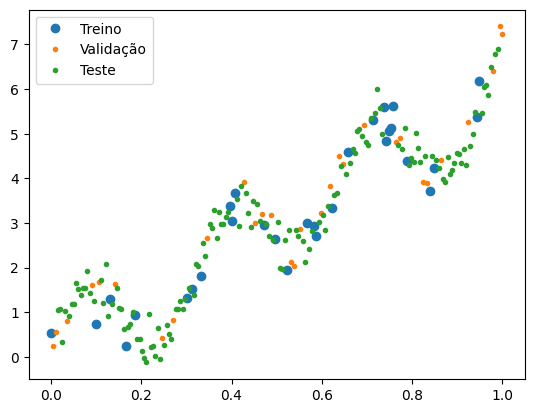

In [28]:
X = X.reshape((-1, 1))
Y = Y.reshape((-1, 1))

# Separação do desenvolvimento (30) e teste (70)
X_dev, X_test, Y_dev, Y_test = train_test_split(X, Y, test_size=0.7, random_state=3)

# Separação em treino (80) e validação (20)
X_train, X_val, Y_train, Y_val = train_test_split(X_dev, Y_dev, test_size=0.5, random_state=3)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

plt.plot(X_train, Y_train, 'o', label='Treino')
plt.plot(X_val, Y_val, '.', label='Validação')
plt.plot(X_test, Y_test, '.', label='Teste')
plt.legend()
plt.show()

In [29]:
x_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(Y_train)

x_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(Y_val)

x_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(Y_test)

In [30]:
class MLP(nn.Module):
  def __init__(self, input_dim, output_dim):
    super(MLP, self).__init__()
    self.rede = nn.Sequential(
        nn.Linear(input_dim, 512),
        nn.Tanh(),
        nn.Linear(512, 256),
        nn.Tanh(),
        nn.Linear(256, 128),
        nn.Tanh(),
        nn.Linear(128, 64),
        nn.Tanh(),
        nn.Linear(64, output_dim)
    )
  def forward(self, x):
    out = self.rede(x)
    return out

In [31]:
input_dim = 1
output_dim = 1

modelo = MLP(input_dim, output_dim)

In [32]:
from torchsummary import summary
print(modelo)
summary(modelo, (1, 1))

MLP(
  (rede): Sequential(
    (0): Linear(in_features=1, out_features=512, bias=True)
    (1): Tanh()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1               [-1, 1, 512]           1,024
              Tanh-2               [-1, 1, 512]               0
            Linear-3               [-1, 1, 256]         131,328
              Tanh-4               [-1, 1, 256]               0
            Linear-5               [-1, 1, 128]          32,896
              Tanh-6               [-1, 1, 128]               0
            Linear-7                [-1, 1, 64]           8,256
              Tanh-8  

In [33]:
eta = 0.02
loss_function = nn.MSELoss()
optimizer = torch.optim.SGD(modelo.parameters(), lr=eta)

In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [35]:
def train_network(model, optimizer, loss_function, x_train, y_train, x_val, y_val, num_epochs, train_losses, val_losses):
  for epoch in range(num_epochs):

    # Zerando gradientes da época anterior
    optimizer.zero_grad()

    # Fase de propagação
    output_train = model(x_train)

    # Cálculo do erro (função de custo)
    loss_train = loss_function(output_train, y_train)

    # Fase de retropropagação
    loss_train.backward()

    # Atualização dos pesos da rede
    optimizer.step()

    # Fase de validação
    output_val = model(x_val)
    loss_val = loss_function(output_val, y_val)

    train_losses[epoch] = loss_train.item()
    val_losses[epoch] = loss_val.item()

    if (epoch + 1) % 500 == 0:
      print(f'Epoch {epoch + 1}/{num_epochs}, Erro Treino: {train_losses[epoch]:.4f}, Erro Validação: {val_losses[epoch]:.4f}')

In [36]:
num_epochs = 10000
train_losses = np.zeros(num_epochs)
val_losses = np.zeros(num_epochs)

train_network(modelo, optimizer, loss_function, x_train, y_train, x_val, y_val, num_epochs, train_losses, val_losses)

Epoch 500/10000, Erro Treino: 0.4674, Erro Validação: 0.7109
Epoch 1000/10000, Erro Treino: 0.3906, Erro Validação: 0.7652
Epoch 1500/10000, Erro Treino: 0.3034, Erro Validação: 0.8263
Epoch 2000/10000, Erro Treino: 0.2359, Erro Validação: 0.7259
Epoch 2500/10000, Erro Treino: 0.2206, Erro Validação: 0.6678
Epoch 3000/10000, Erro Treino: 0.2131, Erro Validação: 0.6332
Epoch 3500/10000, Erro Treino: 0.1814, Erro Validação: 0.5519
Epoch 4000/10000, Erro Treino: 0.2921, Erro Validação: 0.5080
Epoch 4500/10000, Erro Treino: 0.0908, Erro Validação: 0.2645
Epoch 5000/10000, Erro Treino: 0.0769, Erro Validação: 0.2566
Epoch 5500/10000, Erro Treino: 0.0757, Erro Validação: 0.2984
Epoch 6000/10000, Erro Treino: 0.0736, Erro Validação: 0.2861
Epoch 6500/10000, Erro Treino: 0.0721, Erro Validação: 0.2763
Epoch 7000/10000, Erro Treino: 0.0709, Erro Validação: 0.2688
Epoch 7500/10000, Erro Treino: 0.0698, Erro Validação: 0.2623
Epoch 8000/10000, Erro Treino: 0.0689, Erro Validação: 0.2565
Epoch 850

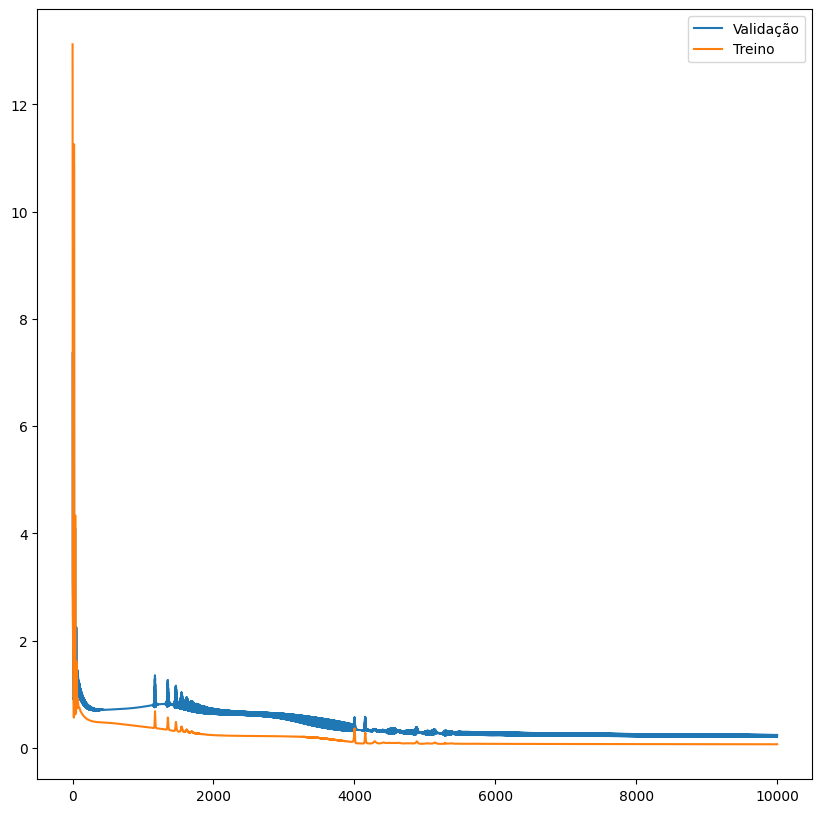

In [37]:
plt.figure(figsize=(10, 10))
plt.plot(val_losses, label='Validação')
plt.plot(train_losses, label='Treino')
plt.legend()
plt.show()

In [38]:
predictions_train = []
predictions_val = []
predictions_test = []
with torch.no_grad():
  predictions_train = modelo(x_train)
  predictions_val = modelo(x_val)
  predictions_test = modelo(x_test)

  erro_train = loss_function(predictions_train, y_train)
  erro_val = loss_function(predictions_val, y_val)
  erro_test = loss_function(predictions_test, y_test)

  print(f"Erro Treino: {erro_train}")
  print(f"Erro Validação: {erro_val}")
  print(f"Erro Teste: {erro_test}")

Erro Treino: 0.06533195823431015
Erro Validação: 0.2390109896659851
Erro Teste: 0.2043004333972931


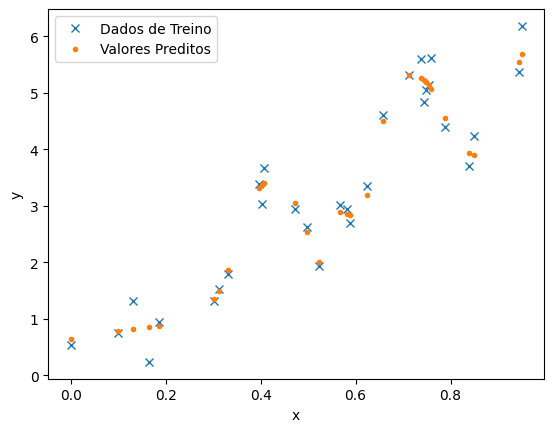

In [39]:
plt.plot(x_train, y_train, 'x', label='Dados de Treino')
plt.plot(x_train, predictions_train, '.', label = 'Valores Preditos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

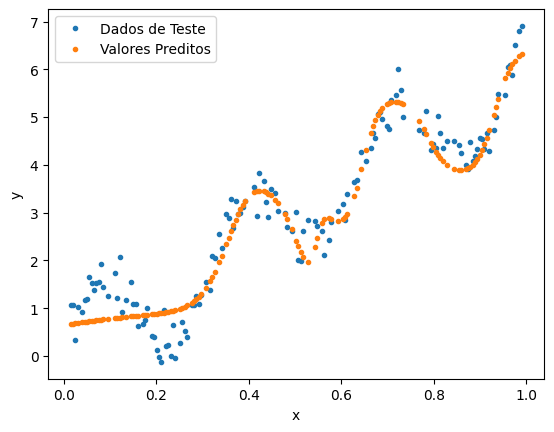

In [40]:
plt.plot(x_test, y_test, '.', label='Dados de Teste')
plt.plot(x_test, predictions_test, '.', label = 'Valores Preditos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

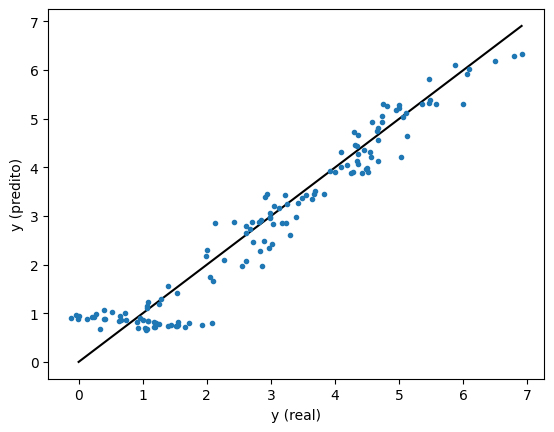

In [41]:
plt.plot([0, torch.max(y_test)], [0, torch.max(y_test)], 'black')
plt.plot(y_test, predictions_test, '.')
plt.xlabel('y (real)')
plt.ylabel('y (predito)')
plt.show()

In [42]:
input_dim = 1
output_dim = 1

modelo2 = MLP(input_dim, output_dim)

In [43]:
eta = 0.02
mom = 0.5
loss_function = nn.MSELoss()
optimizer = torch.optim.SGD(modelo2.parameters(), lr=eta, momentum=mom)

In [44]:
num_epochs = 10000
train_losses2 = np.zeros(num_epochs)
val_losses2 = np.zeros(num_epochs)

train_network(modelo2, optimizer, loss_function, x_train, y_train, x_val, y_val, num_epochs, train_losses2, val_losses2)

Epoch 500/10000, Erro Treino: 0.3858, Erro Validação: 0.7887
Epoch 1000/10000, Erro Treino: 0.2242, Erro Validação: 0.6372
Epoch 1500/10000, Erro Treino: 0.1359, Erro Validação: 0.4030
Epoch 2000/10000, Erro Treino: 0.0743, Erro Validação: 0.2201
Epoch 2500/10000, Erro Treino: 0.0653, Erro Validação: 0.2011
Epoch 3000/10000, Erro Treino: 0.0617, Erro Validação: 0.1868
Epoch 3500/10000, Erro Treino: 0.0600, Erro Validação: 0.1780
Epoch 4000/10000, Erro Treino: 0.0616, Erro Validação: 0.1910
Epoch 4500/10000, Erro Treino: 0.0600, Erro Validação: 0.1831
Epoch 5000/10000, Erro Treino: 0.0592, Erro Validação: 0.1798
Epoch 5500/10000, Erro Treino: 0.0587, Erro Validação: 0.1782
Epoch 6000/10000, Erro Treino: 0.0585, Erro Validação: 0.1774
Epoch 6500/10000, Erro Treino: 0.0582, Erro Validação: 0.1767
Epoch 7000/10000, Erro Treino: 0.0578, Erro Validação: 0.1756
Epoch 7500/10000, Erro Treino: 0.0575, Erro Validação: 0.1743
Epoch 8000/10000, Erro Treino: 0.0573, Erro Validação: 0.1712
Epoch 850

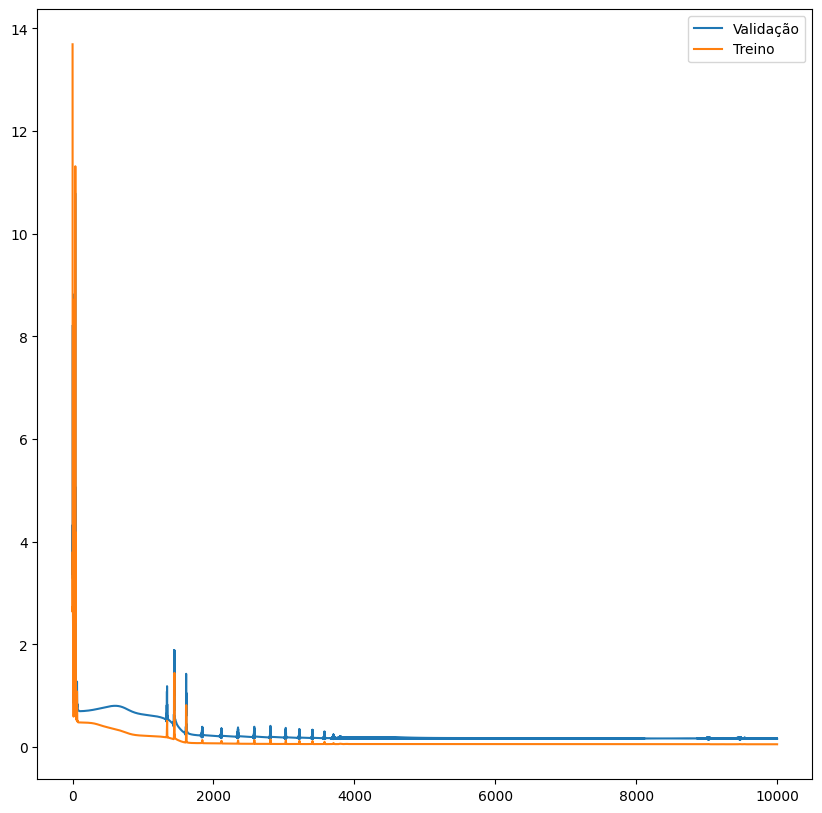

In [45]:
plt.figure(figsize=(10, 10))
plt.plot(val_losses2, label='Validação')
plt.plot(train_losses2, label='Treino')
plt.legend()
plt.show()

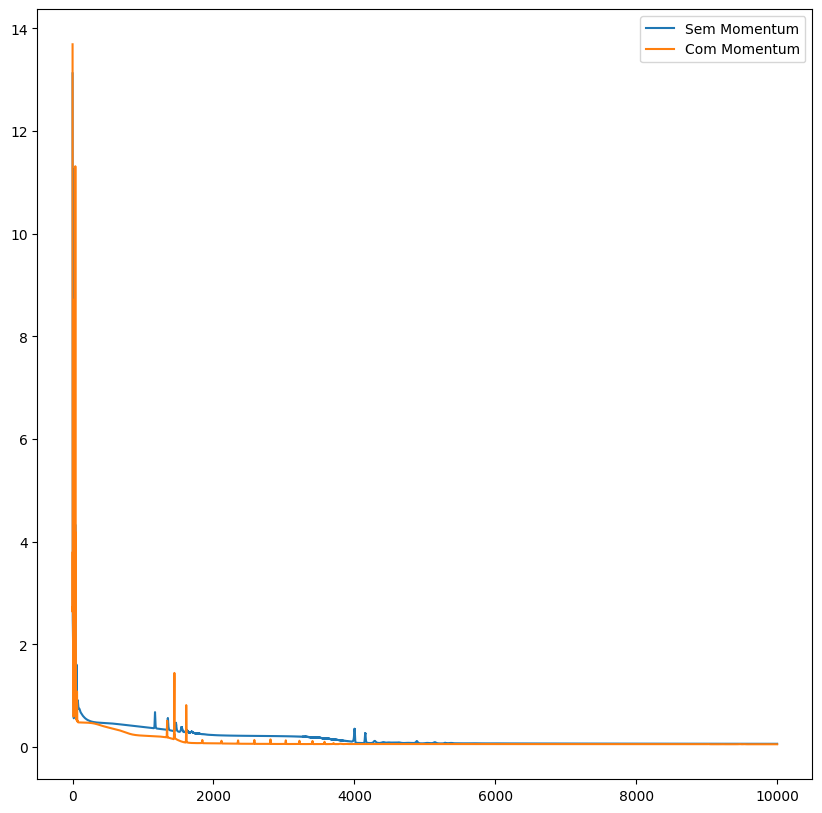

In [46]:
plt.figure(figsize= (10, 10))
plt.plot(train_losses, label='Sem Momentum')
plt.plot(train_losses2, label='Com Momentum')
plt.legend()
plt.show()


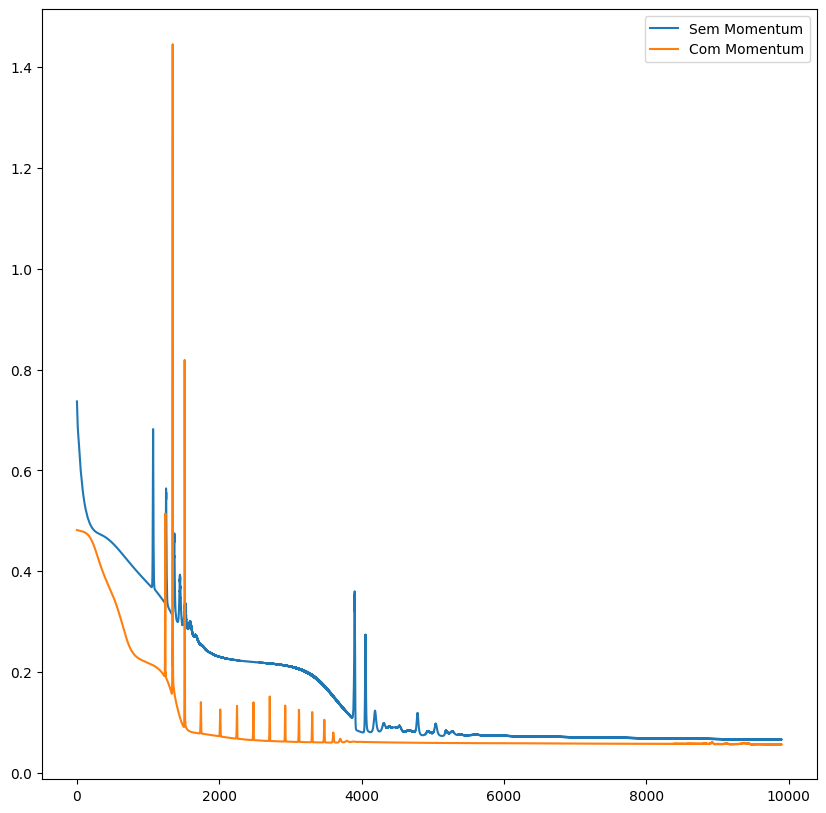

In [47]:
plt.figure(figsize= (10, 10))
plt.plot(train_losses[100:], label='Sem Momentum')
plt.plot(train_losses2[100:], label='Com Momentum')
plt.legend()
plt.show()

In [49]:
predictions_train2 = []
predictions_val2 = []
predictions_test2 = []
with torch.no_grad():
  predictions_train2 = modelo2(x_train)
  predictions_val2 = modelo2(x_val)
  predictions_test2 = modelo2(x_test)

  erro_train2 = loss_function(predictions_train2, y_train)
  erro_val2 = loss_function(predictions_val2, y_val)
  erro_test2 = loss_function(predictions_test2, y_test)

  print(f"Erro Treino: {erro_train2}")
  print(f"Erro Validação: {erro_val2}")
  print(f"Erro Teste: {erro_test2}")

Erro Treino: 0.05676819756627083
Erro Validação: 0.167933389544487
Erro Teste: 0.22779376804828644


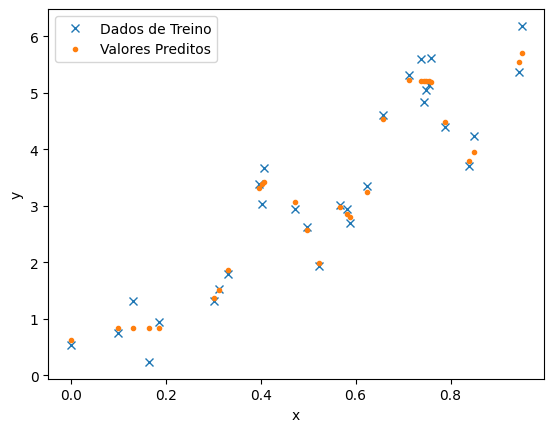

In [50]:
plt.plot(x_train, y_train, 'x', label='Dados de Treino')
plt.plot(x_train, predictions_train2, '.', label = 'Valores Preditos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

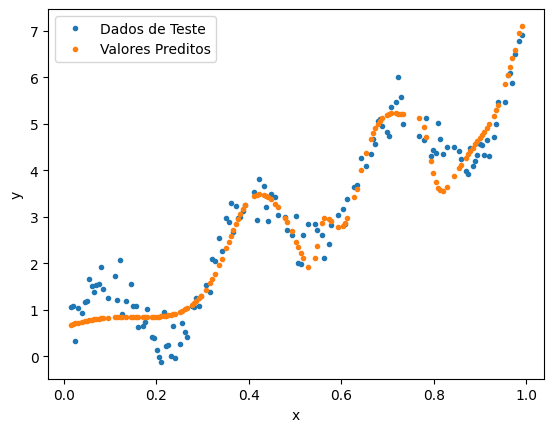

In [51]:
plt.plot(x_test, y_test, '.', label='Dados de Teste')
plt.plot(x_test, predictions_test2, '.', label = 'Valores Preditos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

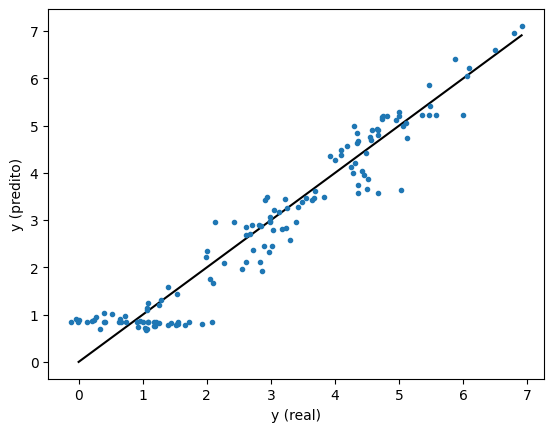

In [52]:
plt.plot([0, torch.max(y_test)], [0, torch.max(y_test)], 'black')
plt.plot(y_test, predictions_test2, '.')
plt.xlabel('y (real)')
plt.ylabel('y (predito)')
plt.show()

ADAM

In [53]:
input_dim = 1
output_dim = 1

modelo3 = MLP(input_dim, output_dim)

In [55]:
eta = 0.001
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(modelo3.parameters(), lr=eta)

In [56]:
num_epochs = 10000
train_losses3 = np.zeros(num_epochs)
val_losses3 = np.zeros(num_epochs)

train_network(modelo3, optimizer, loss_function, x_train, y_train, x_val, y_val, num_epochs, train_losses3, val_losses3)

Epoch 500/10000, Erro Treino: 0.2026, Erro Validação: 0.6587
Epoch 1000/10000, Erro Treino: 0.0569, Erro Validação: 0.3151
Epoch 1500/10000, Erro Treino: 0.0444, Erro Validação: 0.2803
Epoch 2000/10000, Erro Treino: 0.0293, Erro Validação: 0.2239
Epoch 2500/10000, Erro Treino: 0.0249, Erro Validação: 0.2568
Epoch 3000/10000, Erro Treino: 0.0115, Erro Validação: 0.3517
Epoch 3500/10000, Erro Treino: 0.0098, Erro Validação: 0.4144
Epoch 4000/10000, Erro Treino: 0.0026, Erro Validação: 0.4360
Epoch 4500/10000, Erro Treino: 0.0012, Erro Validação: 0.4292
Epoch 5000/10000, Erro Treino: 0.0016, Erro Validação: 0.3961
Epoch 5500/10000, Erro Treino: 0.0004, Erro Validação: 0.3495
Epoch 6000/10000, Erro Treino: 0.0002, Erro Validação: 0.3455
Epoch 6500/10000, Erro Treino: 0.0076, Erro Validação: 0.4019
Epoch 7000/10000, Erro Treino: 0.0024, Erro Validação: 0.4583
Epoch 7500/10000, Erro Treino: 0.0073, Erro Validação: 0.4273
Epoch 8000/10000, Erro Treino: 0.0056, Erro Validação: 0.3833
Epoch 850

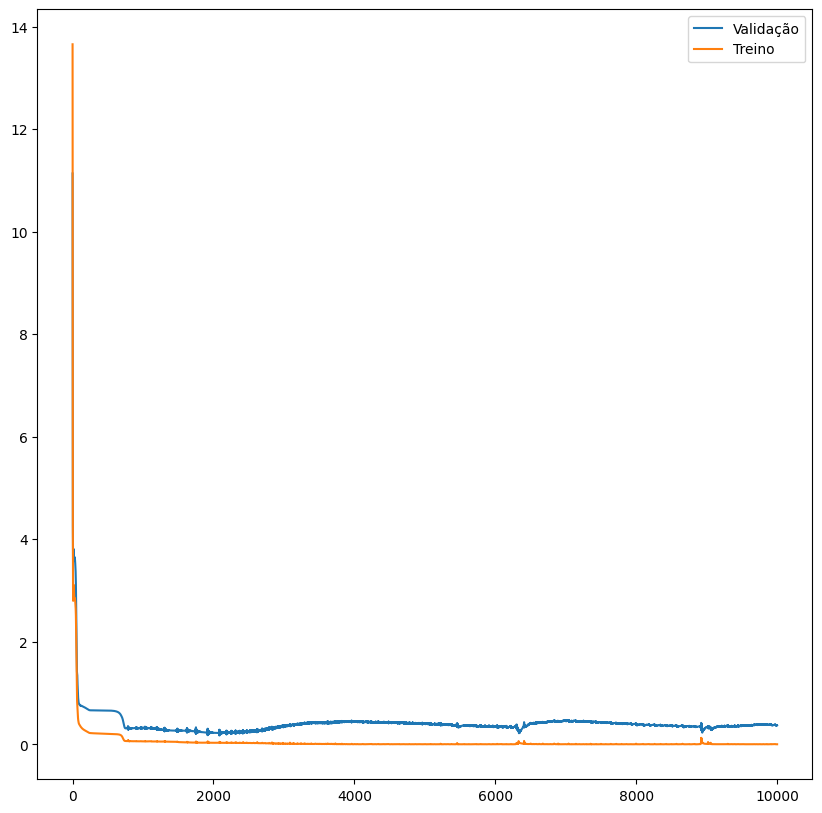

In [57]:
plt.figure(figsize=(10, 10))
plt.plot(val_losses3, label='Validação')
plt.plot(train_losses3, label='Treino')
plt.legend()
plt.show()

In [58]:
predictions_train3 = []
predictions_val3 = []
predictions_test3 = []
with torch.no_grad():
  predictions_train3 = modelo3(x_train)
  predictions_val3 = modelo3(x_val)
  predictions_test3 = modelo3(x_test)

  erro_train3 = loss_function(predictions_train3, y_train)
  erro_val3 = loss_function(predictions_val3, y_val)
  erro_test3 = loss_function(predictions_test3, y_test)

  print(f"Erro Treino: {erro_train3}")
  print(f"Erro Validação: {erro_val3}")
  print(f"Erro Teste: {erro_test3}")

Erro Treino: 0.00023189368948806077
Erro Validação: 0.3708285987377167
Erro Teste: 0.46466881036758423


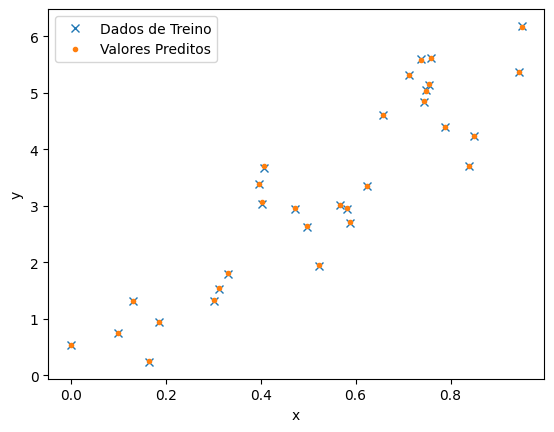

In [59]:
plt.plot(x_train, y_train, 'x', label='Dados de Treino')
plt.plot(x_train, predictions_train3, '.', label = 'Valores Preditos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

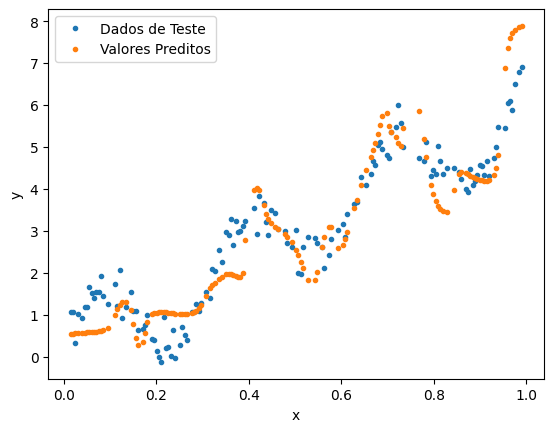

In [60]:
plt.plot(x_test, y_test, '.', label='Dados de Teste')
plt.plot(x_test, predictions_test3, '.', label = 'Valores Preditos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

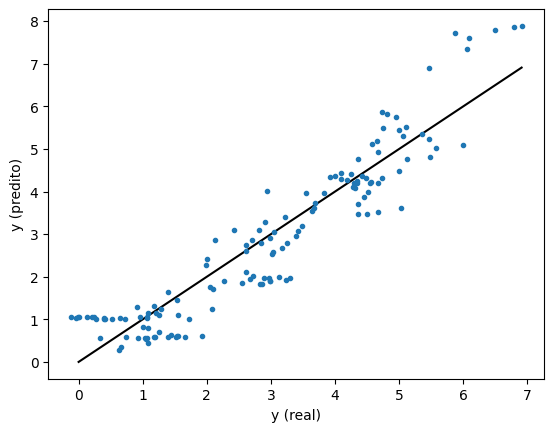

In [61]:
plt.plot([0, torch.max(y_test)], [0, torch.max(y_test)], 'black')
plt.plot(y_test, predictions_test3, '.')
plt.xlabel('y (real)')
plt.ylabel('y (predito)')
plt.show()

Regularização L2

In [62]:
input_dim = 1
output_dim = 1

modelo4 = MLP(input_dim, output_dim)

In [63]:
eta = 0.001
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(modelo4.parameters(),
                             lr=eta,
                             weight_decay=0.001)

In [64]:
num_epochs = 10000
train_losses4 = np.zeros(num_epochs)
val_losses4 = np.zeros(num_epochs)

train_network(modelo4, optimizer, loss_function, x_train, y_train, x_val, y_val, num_epochs, train_losses4, val_losses4)

Epoch 500/10000, Erro Treino: 0.1590, Erro Validação: 0.5771
Epoch 1000/10000, Erro Treino: 0.0718, Erro Validação: 0.2393
Epoch 1500/10000, Erro Treino: 0.0659, Erro Validação: 0.2312
Epoch 2000/10000, Erro Treino: 0.0605, Erro Validação: 0.2133
Epoch 2500/10000, Erro Treino: 0.0581, Erro Validação: 0.1987
Epoch 3000/10000, Erro Treino: 0.1137, Erro Validação: 0.1758
Epoch 3500/10000, Erro Treino: 0.0590, Erro Validação: 0.2096
Epoch 4000/10000, Erro Treino: 0.0574, Erro Validação: 0.1859
Epoch 4500/10000, Erro Treino: 0.0573, Erro Validação: 0.1846
Epoch 5000/10000, Erro Treino: 0.0575, Erro Validação: 0.1827
Epoch 5500/10000, Erro Treino: 0.1736, Erro Validação: 0.1716
Epoch 6000/10000, Erro Treino: 0.0575, Erro Validação: 0.1870
Epoch 6500/10000, Erro Treino: 0.0577, Erro Validação: 0.1790
Epoch 7000/10000, Erro Treino: 0.0579, Erro Validação: 0.1741
Epoch 7500/10000, Erro Treino: 0.0605, Erro Validação: 0.2081
Epoch 8000/10000, Erro Treino: 0.0579, Erro Validação: 0.1761
Epoch 850

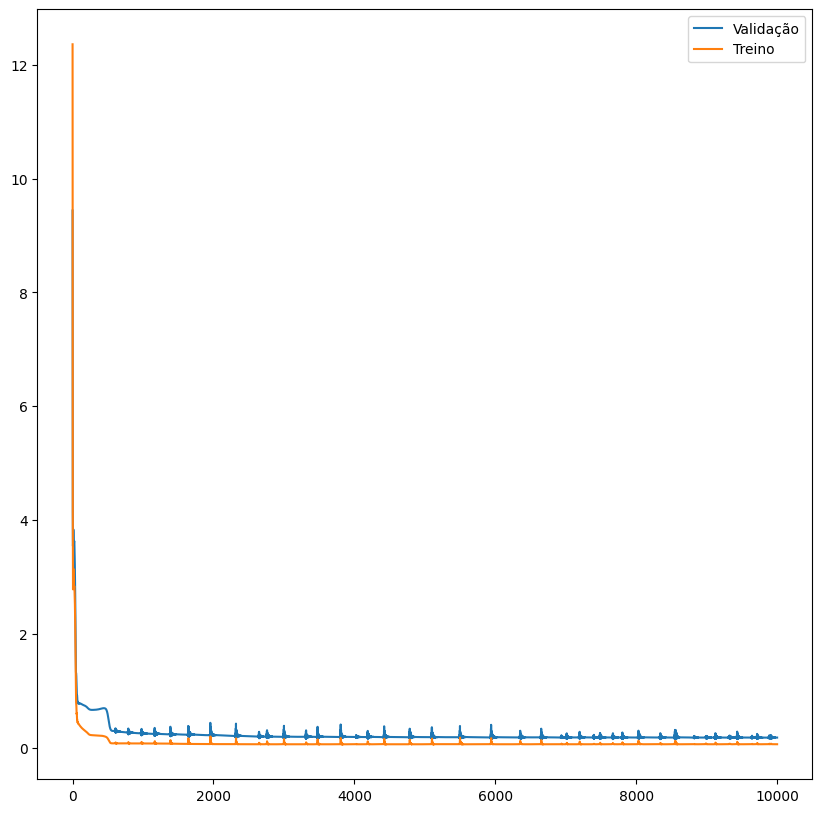

In [65]:
plt.figure(figsize=(10, 10))
plt.plot(val_losses4, label='Validação')
plt.plot(train_losses4, label='Treino')
plt.legend()
plt.show()

In [66]:
predictions_train4 = []
predictions_val4 = []
predictions_test4 = []
with torch.no_grad():
  predictions_train4 = modelo4(x_train)
  predictions_val4 = modelo4(x_val)
  predictions_test4 = modelo4(x_test)

  erro_train4 = loss_function(predictions_train4, y_train)
  erro_val4 = loss_function(predictions_val4, y_val)
  erro_test4 = loss_function(predictions_test4, y_test)

  print(f"Erro Treino: {erro_train4}")
  print(f"Erro Validação: {erro_val4}")
  print(f"Erro Teste: {erro_test4}")

Erro Treino: 0.05798742547631264
Erro Validação: 0.17499962449073792
Erro Teste: 0.19580988585948944


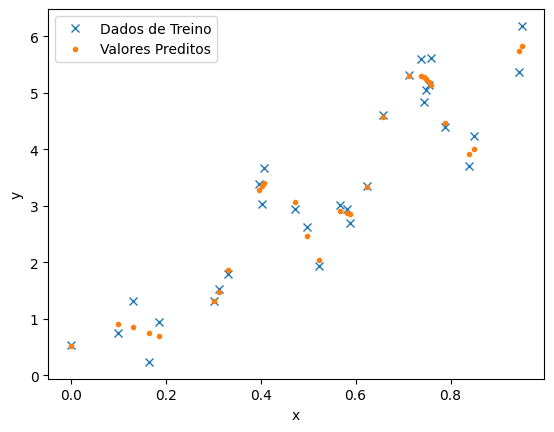

In [67]:
plt.plot(x_train, y_train, 'x', label='Dados de Treino')
plt.plot(x_train, predictions_train4, '.', label = 'Valores Preditos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

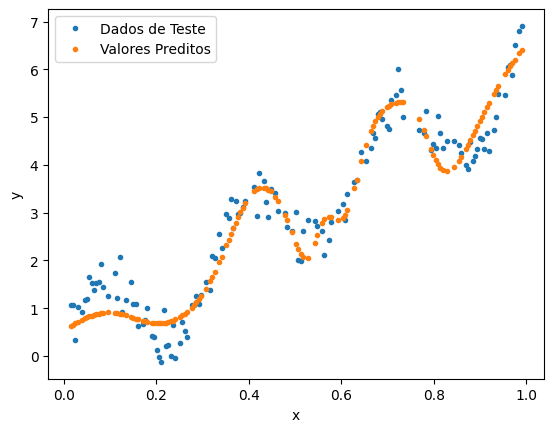

In [68]:
plt.plot(x_test, y_test, '.', label='Dados de Teste')
plt.plot(x_test, predictions_test4, '.', label = 'Valores Preditos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

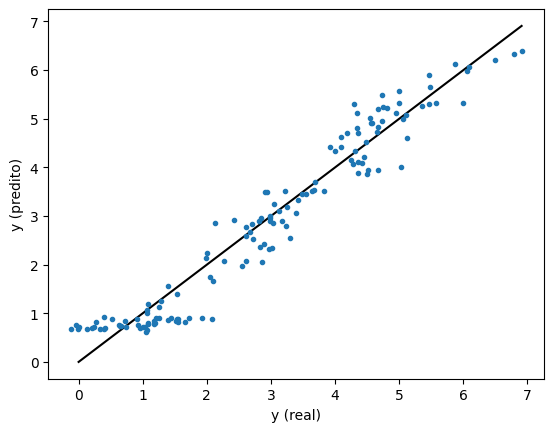

In [69]:
plt.plot([0, torch.max(y_test)], [0, torch.max(y_test)], 'black')
plt.plot(y_test, predictions_test4, '.')
plt.xlabel('y (real)')
plt.ylabel('y (predito)')
plt.show()

Regularizaçao L2 Alta

In [70]:
input_dim = 1
output_dim = 1

modelo5 = MLP(input_dim, output_dim)

In [71]:
eta = 0.001
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(modelo5.parameters(),
                             lr=eta,
                             weight_decay=0.05)

In [72]:
num_epochs = 3000
train_losses5 = np.zeros(num_epochs)
val_losses5 = np.zeros(num_epochs)

train_network(modelo5, optimizer, loss_function, x_train, y_train, x_val, y_val, num_epochs, train_losses5, val_losses5)

Epoch 500/3000, Erro Treino: 0.4896, Erro Validação: 0.7109
Epoch 1000/3000, Erro Treino: 0.4955, Erro Validação: 0.6934
Epoch 1500/3000, Erro Treino: 0.5057, Erro Validação: 0.6829
Epoch 2000/3000, Erro Treino: 0.5039, Erro Validação: 0.6784
Epoch 2500/3000, Erro Treino: 0.5036, Erro Validação: 0.6763
Epoch 3000/3000, Erro Treino: 0.5034, Erro Validação: 0.6743


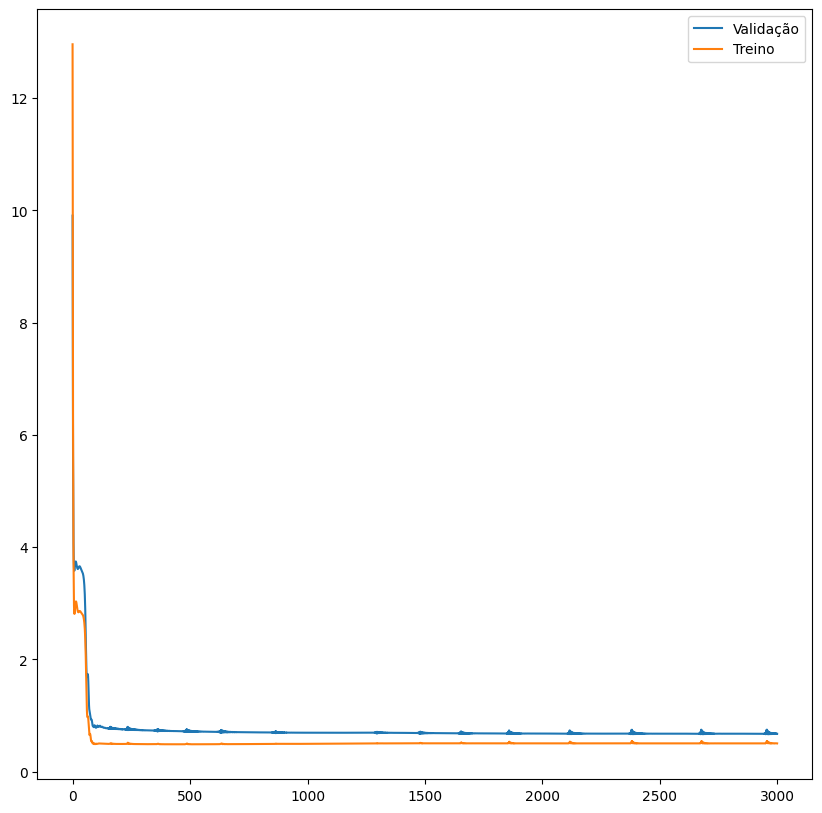

In [73]:
plt.figure(figsize=(10, 10))
plt.plot(val_losses5, label='Validação')
plt.plot(train_losses5, label='Treino')
plt.legend()
plt.show()

In [74]:
predictions_train5 = []
predictions_val5 = []
predictions_test5 = []
with torch.no_grad():
  predictions_train5 = modelo5(x_train)
  predictions_val5 = modelo5(x_val)
  predictions_test5 = modelo5(x_test)

  erro_train5 = loss_function(predictions_train5, y_train)
  erro_val5 = loss_function(predictions_val5, y_val)
  erro_test5 = loss_function(predictions_test5, y_test)

  print(f"Erro Treino: {erro_train5}")
  print(f"Erro Validação: {erro_val5}")
  print(f"Erro Teste: {erro_test5}")

Erro Treino: 0.503390908241272
Erro Validação: 0.6743119359016418
Erro Teste: 0.6344540119171143


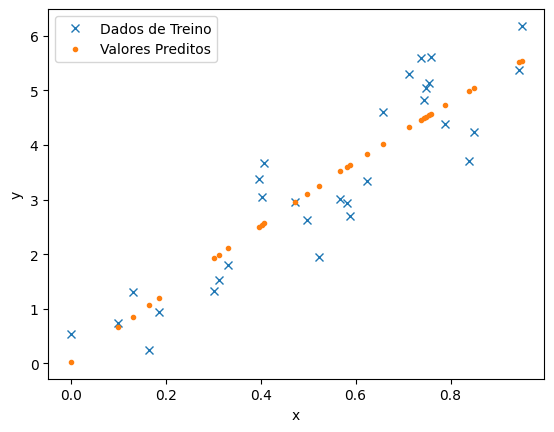

In [75]:
plt.plot(x_train, y_train, 'x', label='Dados de Treino')
plt.plot(x_train, predictions_train5, '.', label = 'Valores Preditos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

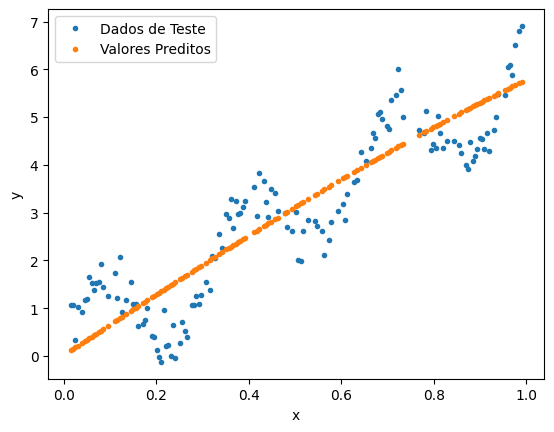

In [76]:
plt.plot(x_test, y_test, '.', label='Dados de Teste')
plt.plot(x_test, predictions_test5, '.', label = 'Valores Preditos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

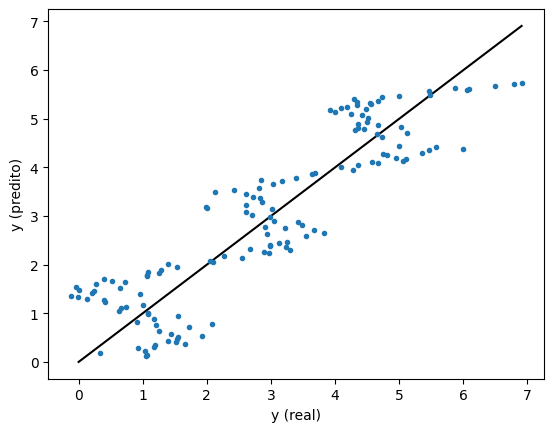

In [77]:
plt.plot([0, torch.max(y_test)], [0, torch.max(y_test)], 'black')
plt.plot(y_test, predictions_test5, '.')
plt.xlabel('y (real)')
plt.ylabel('y (predito)')
plt.show()

Regularização OK

In [78]:
input_dim = 1
output_dim = 1

modelo6 = MLP(input_dim, output_dim)

In [79]:
eta = 0.001
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(modelo6.parameters(),
                             lr=eta,
                             weight_decay=0.005)

In [80]:
num_epochs = 3000
train_losses6 = np.zeros(num_epochs)
val_losses6 = np.zeros(num_epochs)

train_network(modelo6, optimizer, loss_function, x_train, y_train, x_val, y_val, num_epochs, train_losses6, val_losses6)

Epoch 500/3000, Erro Treino: 0.2247, Erro Validação: 0.6457
Epoch 1000/3000, Erro Treino: 0.2128, Erro Validação: 0.6276
Epoch 1500/3000, Erro Treino: 0.0818, Erro Validação: 0.2287
Epoch 2000/3000, Erro Treino: 0.0771, Erro Validação: 0.1975
Epoch 2500/3000, Erro Treino: 0.0755, Erro Validação: 0.1803
Epoch 3000/3000, Erro Treino: 0.0763, Erro Validação: 0.1847


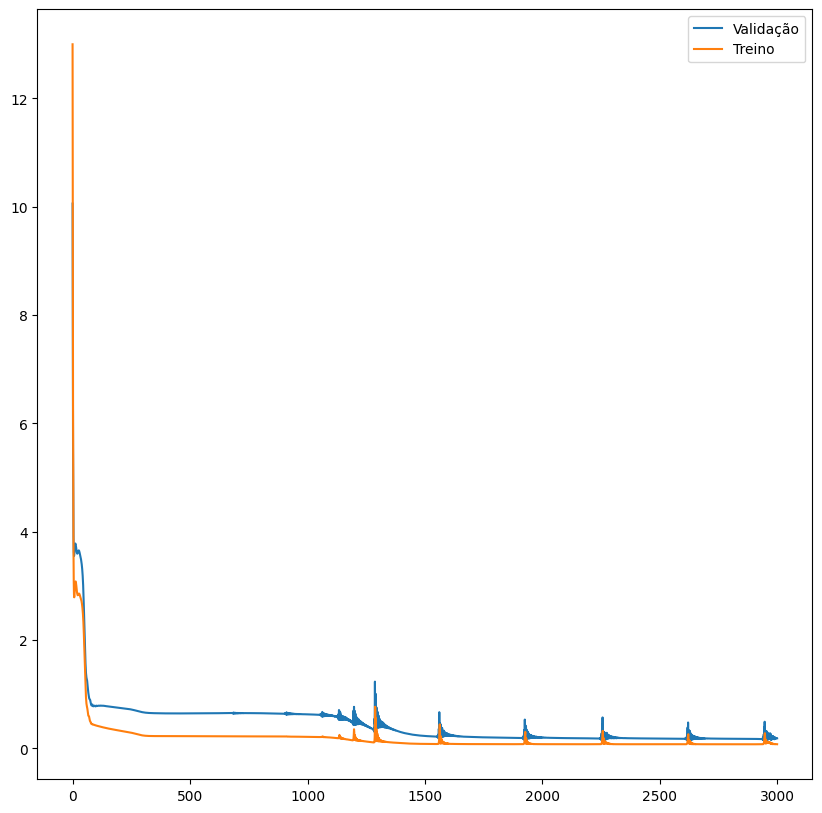

In [81]:
plt.figure(figsize=(10, 10))
plt.plot(val_losses6, label='Validação')
plt.plot(train_losses6, label='Treino')
plt.legend()
plt.show()

In [82]:
predictions_train6 = []
predictions_val6 = []
predictions_test6 = []
with torch.no_grad():
  predictions_train6 = modelo6(x_train)
  predictions_val6 = modelo6(x_val)
  predictions_test6 = modelo6(x_test)

  erro_train6 = loss_function(predictions_train6, y_train)
  erro_val6 = loss_function(predictions_val6, y_val)
  erro_test6 = loss_function(predictions_test6, y_test)

  print(f"Erro Treino: {erro_train6}")
  print(f"Erro Validação: {erro_val6}")
  print(f"Erro Teste: {erro_test6}")

Erro Treino: 0.07655034959316254
Erro Validação: 0.18467020988464355
Erro Teste: 0.2029014676809311


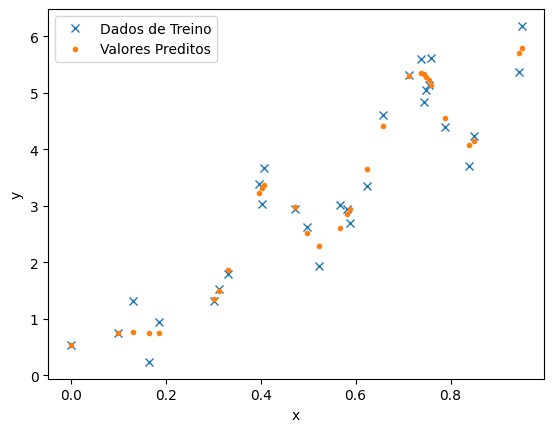

In [83]:
plt.plot(x_train, y_train, 'x', label='Dados de Treino')
plt.plot(x_train, predictions_train6, '.', label = 'Valores Preditos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

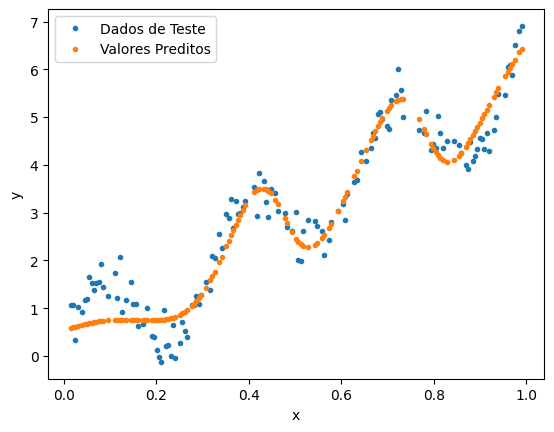

In [84]:
plt.plot(x_test, y_test, '.', label='Dados de Teste')
plt.plot(x_test, predictions_test6, '.', label = 'Valores Preditos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

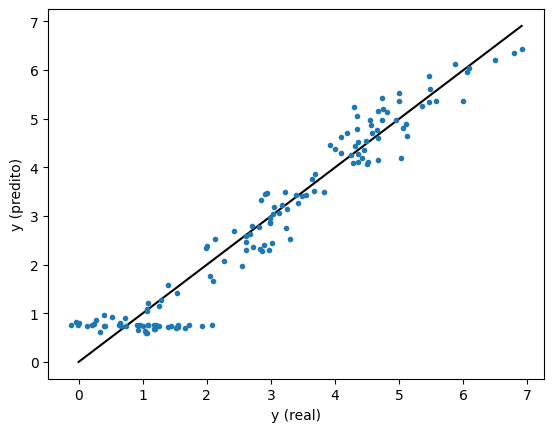

In [85]:
plt.plot([0, torch.max(y_test)], [0, torch.max(y_test)], 'black')
plt.plot(y_test, predictions_test6, '.')
plt.xlabel('y (real)')
plt.ylabel('y (predito)')
plt.show()